# 01 Temporal Vision — Video AI 실습

**제8장 Video AI 처리** | 시공간(Spatiotemporal) 정보 결합 및 모델 아키텍처의 진화

| 섹션 | 주제 |
|------|------|
| 1 | Spatiotemporal Information (공간 vs 시간) |
| 2 | Optical Flow — Farneback / Lucas-Kanade |
| 3 | SlowFast Dual-pathway |
| 4 | 3D CNN — R3D(C3D), MC3(I3D), Swin3D |
| 5 | Video Transformer — TimeSformer, ViViT |
| 6 | 모델 비교 요약 |

### 샘플 비디오
- **Colab**: `!wget https://dl.fbaipublicfiles.com/pytorchvideo/projects/archery.mp4 -O sample_video.mp4`
- **Windows**: `Invoke-WebRequest -Uri "https://dl.fbaipublicfiles.com/pytorchvideo/projects/archery.mp4" -OutFile "sample_video.mp4"`


In [15]:
# 최초 1회 실행
# !pip install -q -r requirements.txt


```
opencv-python>=4.8.0
numpy>=1.24.0
matplotlib>=3.7.0
torch>=2.0.0
torchvision>=0.15.0
transformers>=4.40.0
Pillow>=10.0.0
```

### 환경 및 데이터

| 항목 | 설명 |
|------|------|
| **입력 데이터** | PyTorchVideo 공개 archery.mp4 (양궁 행동 클립) |
| **프레임 처리** | OpenCV `VideoCapture` — BGR numpy 배열로 디코딩 |
| **시각화** | matplotlib + 한글 폰트(맑은 고딕/나눔고딕) 자동 설정 |
| **딥러닝 백엔드** | PyTorch + torchvision(3D CNN) + Hugging Face Transformers |

비디오 AI의 출발점은 **연속 프레임 시퀀스**입니다. 이후 각 섹션은 프레임에서 시간 축 정보를 추출·모델링하는 서로 다른 Vision 기술을 다룹니다.


In [2]:
from __future__ import annotations

import os
import platform
import subprocess
import textwrap
from dataclasses import dataclass
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.gridspec import GridSpec
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# ── 전역 설정 ──────────────────────────────────────────────────────────────

# 샘플 비디오 URL 및 로컬 저장 경로
VIDEO_URL = "https://dl.fbaipublicfiles.com/pytorchvideo/projects/archery.mp4"
VIDEO_PATH = Path("sample_video.mp4")

# 시각화·결과물 저장 디렉터리
OUTPUT_DIR = Path("output")
OPTICAL_FLOW_DIR = OUTPUT_DIR / "optical_flow"
SLOWFAST_DIR = OUTPUT_DIR / "slowfast"
SPATIOTEMPORAL_DIR = OUTPUT_DIR / "spatiotemporal"

# Hugging Face 사전학습 모델 ID (Kinetics-400 fine-tuned)
TIMESFORMER_MODEL_ID = "facebook/timesformer-base-finetuned-k400"
VIVIT_MODEL_ID = "google/vivit-b-16x2-kinetics400"

# Swin3D·ViViT는 가중치 용량(~수백 MB)이 크므로 필요 시 False
RUN_SWIN3D = True
RUN_VIVIT = True

# 각 모델이 요구하는 입력 프레임 수 (모델 아키텍처마다 다름)
TIMESFORMER_NUM_FRAMES = 8    # TimeSformer: 8프레임 클립
VIVIT_NUM_FRAMES = 32         # ViViT: 32프레임, Tubelet(2×16×16) 단위
R3D_NUM_FRAMES = 16           # R3D-18 / MC3-18: 16프레임, 112×112
SWIN3D_NUM_FRAMES = 32        # Swin3D-T: 32프레임, 224×224
SLOWFAST_ALPHA = 4            # SlowFast Fast 경로의 프레임 밀도 배율

# 출력 폴더 선제 생성
for d in (OUTPUT_DIR, OPTICAL_FLOW_DIR, SLOWFAST_DIR, SPATIOTEMPORAL_DIR):
    d.mkdir(parents=True, exist_ok=True)


def is_running_in_colab() -> bool:
    """Google Colab 환경 여부를 확인한다 (다운로드 방식 분기용)."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    """
    matplotlib 한글 폰트를 설정한다.
    Windows → 맑은 고딕, macOS → AppleGothic, Linux/Colab → 나눔고딕
    """
    from matplotlib import font_manager

    if is_running_in_colab():
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)

    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic", "UnDotum"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")

    available = {font.name for font in font_manager.fontManager.ttflist}
    chosen = next((name for name in candidates if name in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback is not None and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        prop = font_manager.FontProperties(fname=str(fallback))
        plt.rcParams["font.family"] = prop.get_name()

    # 한글 폰트 사용 시 마이너스 기호가 깨지는 현상 방지
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_korean()
print("환경 설정 완료")


c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


환경 설정 완료


In [3]:
def download_sample_video(
    url: str = VIDEO_URL,
    output_path: Path = VIDEO_PATH,
) -> Path:
    """
    실행 환경(Colab / Windows / Linux)에 맞는 방법으로 샘플 비디오를 내려받는다.
    이미 파일이 있으면 재다운로드를 건너뛴다.
    """
    output_path = Path(output_path)
    if output_path.exists():
        print(f"[다운로드] 기존 파일 사용: {output_path.resolve()}")
        return output_path

    print(f"[다운로드] {url}\n           -> {output_path.resolve()}")
    if is_running_in_colab():
        subprocess.run(["wget", url, "-O", str(output_path)], check=True)
    elif platform.system() == "Windows":
        subprocess.run(
            ["powershell", "-NoProfile", "-Command",
             f'Invoke-WebRequest -Uri "{url}" -OutFile "{output_path}"'],
            check=True,
        )
    else:
        import urllib.request
        urllib.request.urlretrieve(url, output_path)

    print("[다운로드] 완료")
    return output_path


def read_all_frames_bgr(video_path: Path) -> list[np.ndarray]:
    """
    비디오 전체 프레임을 메모리에 BGR numpy 배열 리스트로 읽는다.
    shape: (H, W, 3), dtype=uint8
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"비디오를 열 수 없습니다: {video_path}")

    frames: list[np.ndarray] = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(frame)
    cap.release()

    if not frames:
        raise ValueError("비디오에서 프레임을 읽지 못했습니다.")
    return frames


def sample_frame_indices(total_frames: int, num_frames: int) -> np.ndarray:
    """
    전체 프레임 길이에서 num_frames개를 균등 간격(linear)으로 샘플링한다.
    비디오 분류 모델은 보통 고정 길이 클립을 입력으로 받으므로 필수 전처리다.
    """
    return np.linspace(0, max(total_frames - 1, 0), num=num_frames, dtype=int)


def read_sampled_rgb_frames(video_path: Path, num_frames: int) -> list[np.ndarray]:
    """
    균등 샘플링된 RGB 프레임 리스트를 반환한다.
    Hugging Face processor / torchvision transform 입력 형식에 맞춘다.
    """
    bgr_frames = read_all_frames_bgr(video_path)
    indices = sample_frame_indices(len(bgr_frames), num_frames)
    sampled = [cv2.cvtColor(bgr_frames[i], cv2.COLOR_BGR2RGB) for i in indices]
    # 프레임 수가 부족하면 마지막 프레임을 반복해 길이를 맞춘다
    while len(sampled) < num_frames:
        sampled.append(sampled[-1])
    return sampled[:num_frames]


@dataclass
class VideoMetadata:
    """비디오의 시공간(Spatial + Temporal) 메타 정보를 담는 데이터 클래스."""
    path: Path
    frame_count: int   # 총 프레임 수 (Temporal 축 길이)
    fps: float           # 초당 프레임 수 (시간 해상도)
    width: int           # Spatial: 가로 해상도
    height: int          # Spatial: 세로 해상도
    duration_sec: float  # 재생 시간(초) = frame_count / fps

    def summary(self) -> str:
        return textwrap.dedent(f"""
            [비디오 메타데이터]
              경로     : {self.path}
              해상도   : {self.width} x {self.height}  (Spatial — 공간)
              FPS      : {self.fps:.2f}               (Temporal — 시간)
              프레임 수: {self.frame_count}
              길이     : {self.duration_sec:.2f} 초
        """).strip()


def analyze_video_metadata(video_path: Path) -> VideoMetadata:
    """
    OpenCV CAP_PROP_* 속성으로 Spatial·Temporal 메타 정보를 추출한다.
    일부 코덱은 FRAME_COUNT를 제공하지 않으므로 전체 읽기로 대체한다.
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"비디오를 열 수 없습니다: {video_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = float(cap.get(cv2.CAP_PROP_FPS)) or 30.0
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    if frame_count <= 0:
        frame_count = len(read_all_frames_bgr(video_path))

    duration = frame_count / fps if fps > 0 else 0.0
    return VideoMetadata(video_path, frame_count, fps, width, height, duration)


## 1. 시공간(Spatiotemporal) 정보


| 구분 | Spatial Context (공간) | Temporal Context (시간) |
|------|------------------------|-------------------------|
| **정의** | 단일 프레임 내 객체의 형태·색상·질감 | 프레임 간 변화, 움직임 궤적, 사건 순서 |
| **담당 모델** | CNN, ViT (2D 정적 특징) | Optical Flow, 3D CNN, Video Transformer |
| **본 섹션 기법** | 프레임 격자 미리보기 | 프레임 차분 `\|F(t+1)-F(t)\|`, Motion Energy 타임라인 |

**핵심 개념:** 비디오 AI는 2D 이미지 분석(Spatial)과 시간 축 분석(Temporal)을 **결합**해야 한다. 프레임 차분은 가장 단순한 Temporal 특징으로, 픽셀 값 변화량이 클수록 움직임이 크다.


In [4]:
def visualize_spatiotemporal_overview(
    video_path: Path,
    *,
    num_preview_frames: int = 8,
    diff_frame_index: int = 10,
    save_path: Path | None = None,
    show: bool = True,
) -> None:
    """
    Spatial(프레임 격자)과 Temporal(프레임 차분) 정보를 한 화면에 시각화한다.

    상단: 시간 축을 따라 균등 샘플링한 8개 프레임 (Spatial 맥락)
    하단 좌: 단일 프레임 (정적 특징)
    하단 우: 연속 두 프레임의 절대 차분 (동적 맥락)
    """
    frames = read_all_frames_bgr(video_path)
    indices = sample_frame_indices(len(frames), num_preview_frames)

    # 그레이스케일 변환 후 절대 차분 → 움직임 영역이 밝게 표시됨
    prev = cv2.cvtColor(frames[diff_frame_index], cv2.COLOR_BGR2GRAY)
    nxt = cv2.cvtColor(frames[diff_frame_index + 1], cv2.COLOR_BGR2GRAY)
    frame_diff = cv2.absdiff(prev, nxt)

    fig = plt.figure(figsize=(15, 8))
    gs = GridSpec(2, num_preview_frames, figure=fig, height_ratios=[1.2, 1.0])
    fig.suptitle("Spatiotemporal Information — Spatial(공간) vs Temporal(시간)", fontsize=14, y=0.98)

    # ── Spatial: 시간 축 프레임 격자 ──
    for col, idx in enumerate(indices):
        ax = fig.add_subplot(gs[0, col])
        ax.imshow(cv2.cvtColor(frames[idx], cv2.COLOR_BGR2RGB))
        ax.set_title(f"t={idx}", fontsize=9)
        ax.axis("off")

    ax_spatial = fig.add_subplot(gs[1, : num_preview_frames // 2])
    ax_spatial.imshow(cv2.cvtColor(frames[diff_frame_index], cv2.COLOR_BGR2RGB))
    ax_spatial.set_title("Spatial — 단일 프레임 (정적 특징)")
    ax_spatial.axis("off")

    ax_temporal = fig.add_subplot(gs[1, num_preview_frames // 2 :])
    ax_temporal.imshow(frame_diff, cmap="hot")  # hot colormap: 움직임=밝은색
    ax_temporal.set_title(
        f"Temporal — 프레임 차분 |F(t+1)-F(t)|  (idx {diff_frame_index}->{diff_frame_index + 1})"
    )
    ax_temporal.axis("off")

    plt.tight_layout()
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Spatiotemporal] 저장: {save_path.resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def compute_motion_energy_timeline(video_path: Path):
    """
    전체 비디오에 대해 프레임별 Motion Energy 프로파일을 계산한다.

    지표 1 — Frame Diff Mean : |F(t+1)-F(t)| 픽셀 평균 (단순 Temporal 특징)
    지표 2 — Flow Magnitude  : Farneback 광학 흐름 크기 평균 (정교한 Temporal 특징)
    """
    frames = read_all_frames_bgr(video_path)
    diff_energy, flow_energy = [], []

    for i in range(len(frames) - 1):
        g0 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        g1 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)

        # 프레임 차분 기반 Motion Energy
        diff_energy.append(float(np.mean(cv2.absdiff(g0, g1))))

        # Farneback Dense Optical Flow → 이동 벡터 크기(magnitude) 평균
        flow = cv2.calcOpticalFlowFarneback(g0, g1, None, 0.5, 3, 15, 3, 5, 1.2, 0)
        mag, _ = cv2.cartToPolar(flow[..., 0], flow[..., 1])
        flow_energy.append(float(np.mean(mag)))

    x = np.arange(1, len(diff_energy) + 1)
    return x, np.array(diff_energy), np.array(flow_energy)


def plot_motion_energy_timeline(video_path: Path, *, save_path: Path | None = None, show: bool = True) -> None:
    """Motion Energy / Optical Flow magnitude를 시간 축 그래프로 시각화한다."""
    x, diff_e, flow_e = compute_motion_energy_timeline(video_path)

    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

    axes[0].plot(x, diff_e, color="#00e5ff", linewidth=1.5)
    axes[0].set_ylabel("Frame Diff Mean")
    axes[0].set_title("Temporal Context — 프레임 차분 기반 Motion Energy")
    axes[0].grid(alpha=0.3)

    axes[1].plot(x, flow_e, color="#76ff03", linewidth=1.5)
    axes[1].set_xlabel("프레임 인덱스 (t → t+1)")
    axes[1].set_ylabel("Flow Magnitude Mean")
    axes[1].set_title("Optical Flow — Farneback 평균 이동량")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Motion Timeline] 저장: {save_path.resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


[다운로드] 기존 파일 사용: C:\MyCursorLab\08_Video AI 처리 및 분석\sample_video.mp4
[비디오 메타데이터]
  경로     : sample_video.mp4
  해상도   : 320 x 240  (Spatial — 공간)
  FPS      : 29.97               (Temporal — 시간)
  프레임 수: 300
  길이     : 10.01 초
[Spatiotemporal] 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output\spatiotemporal\spatial_vs_temporal.png


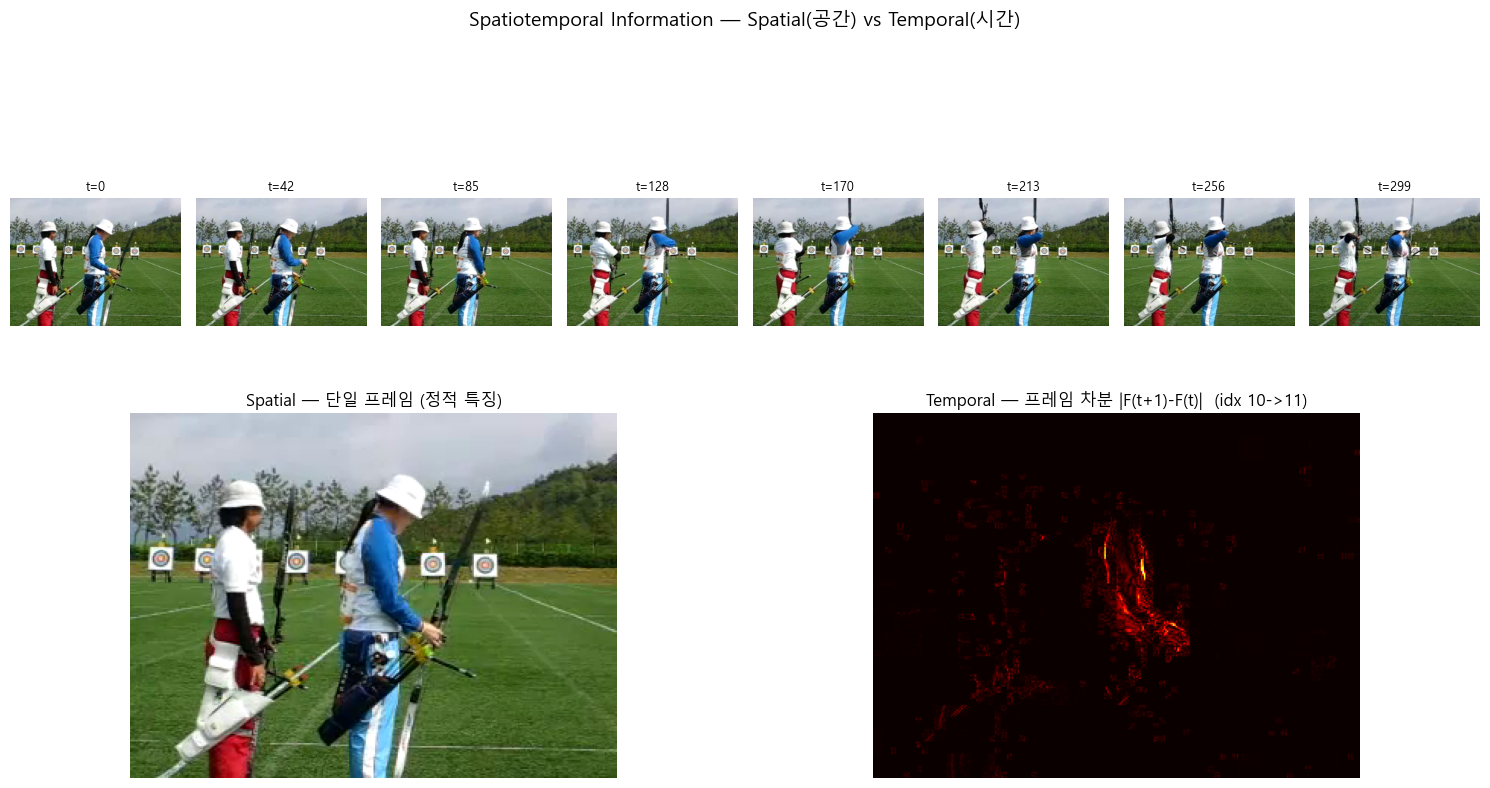

[Motion Timeline] 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output\spatiotemporal\motion_energy_timeline.png


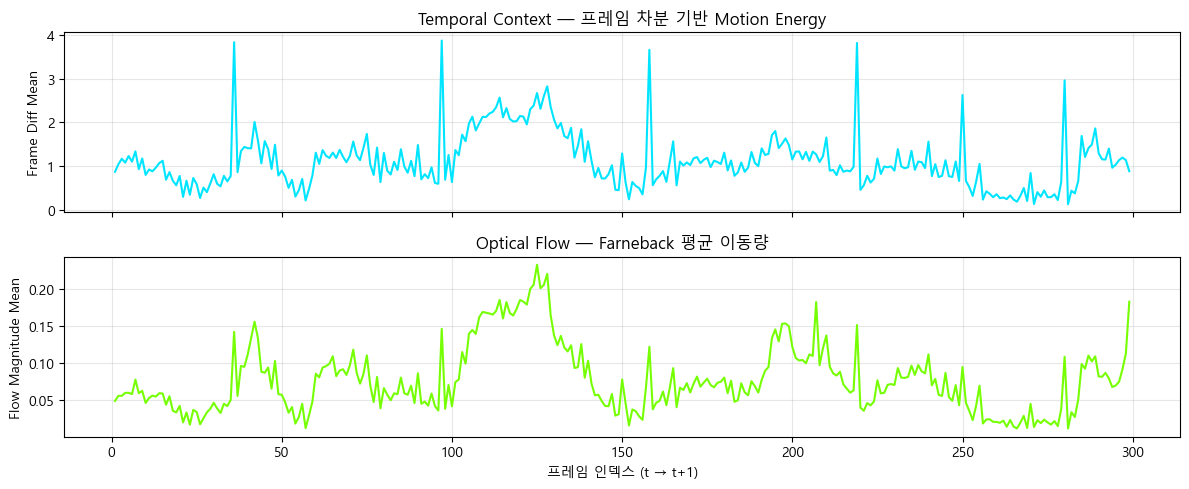

In [5]:
# ── 섹션 1 실행: 시공간 정보 분석 ──
video_path = download_sample_video()

meta = analyze_video_metadata(video_path)
print(meta.summary())

visualize_spatiotemporal_overview(
    video_path,
    save_path=SPATIOTEMPORAL_DIR / "spatial_vs_temporal.png",
)
plot_motion_energy_timeline(
    video_path,
    save_path=SPATIOTEMPORAL_DIR / "motion_energy_timeline.png",
)


## 2. 광학 흐름 (Optical Flow)


| 방법 | 유형 | 원리 | 특징 |
|------|------|------|------|
| **Farneback** | Dense | 다항식 확장으로 **모든 픽셀**의 (dx, dy) 추정 | HSV 컬러맵 시각화에 적합 |
| **Lucas-Kanade** | Sparse | **코너 특징점**만 추적 (goodFeaturesToTrack + PyrLK) | 빠르고 직관적, 벡터 화살표 표시 |

**발전 흐름 (교재):** Classical(기하학) → Deep Learning(FlowNet, PWC-Net) → SOTA(RAFT)

**HSV 컬러맵 규칙:**
- **Hue(색상)** = 이동 **방향** (각도)
- **Value(밝기)** = 이동 **크기** (속력)

OpenCV `calcOpticalFlowFarneback` 파라미터:
- `pyr_scale=0.5` : 이미지 피라미드 축소 비율
- `levels=3` : 피라미드 레벨 (거친→세밀 multi-scale)
- `winsize=15` : 국소 패치(윈도우) 크기


In [6]:
def compute_dense_optical_flow(prev_bgr: np.ndarray, next_bgr: np.ndarray) -> np.ndarray:
    """
    Farneback 알고리즘으로 Dense Optical Flow를 계산한다.
    반환 shape: (H, W, 2) — [:,:,0]=x방향, [:,:,1]=y방향 이동량
    """
    g0 = cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2GRAY)
    g1 = cv2.cvtColor(next_bgr, cv2.COLOR_BGR2GRAY)
    return cv2.calcOpticalFlowFarneback(
        g0, g1, None,
        pyr_scale=0.5, levels=3, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2, flags=0,
    )


def flow_to_hsv_image(flow: np.ndarray) -> np.ndarray:
    """
    (dx, dy) 이동 벡터 필드를 HSV 컬러맵 BGR 이미지로 변환한다.
    cartToPolar: 직교좌표 → 극좌표 (magnitude=크기, angle=방향)
    """
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[..., 0] = (ang * 180 / np.pi / 2).astype(np.uint8)  # Hue: 0~179
    hsv[..., 1] = 255                                       # Saturation: 최대
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)  # Value: 크기
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)


def compute_sparse_optical_flow_lk(prev_bgr: np.ndarray, next_bgr: np.ndarray) -> np.ndarray:
    """
    Lucas-Kanade 피라미드 방식으로 Sparse Optical Flow를 계산한다.

    1) goodFeaturesToTrack: Shi-Tomasi 코너 검출 (최대 200개)
    2) calcOpticalFlowPyrLK: 코너 점을 다음 프레임에서 추적
    3) 추적 성공 점에 화살표(이동 벡터)를 그린다
    """
    g0 = cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2GRAY)
    g1 = cv2.cvtColor(next_bgr, cv2.COLOR_BGR2GRAY)

    feature_params = dict(maxCorners=200, qualityLevel=0.01, minDistance=7, blockSize=7)
    lk_params = dict(
        winSize=(15, 15), maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
    )

    p0 = cv2.goodFeaturesToTrack(g0, mask=None, **feature_params)
    if p0 is None:
        return next_bgr.copy()

    p1, st, _ = cv2.calcOpticalFlowPyrLK(g0, g1, p0, None, **lk_params)
    vis = next_bgr.copy()
    if p1 is None:
        return vis

    # OpenCV 특징점 shape: (N, 1, 2) — ravel()로 (x, y) 좌표 추출
    for pt0, pt1, status in zip(p0, p1, st):
        if status[0] == 1:  # 추적 성공한 점만
            x0, y0 = pt0.ravel()
            x1, y1 = pt1.ravel()
            cv2.arrowedLine(vis, (int(x0), int(y0)), (int(x1), int(y1)), (0, 255, 0), 1, tipLength=0.3)
            cv2.circle(vis, (int(x1), int(y1)), 2, (0, 0, 255), -1)
    return vis


def visualize_optical_flow_comparison(
    prev_bgr: np.ndarray, next_bgr: np.ndarray,
    *, save_path: Path | None = None, show: bool = True,
) -> None:
    """Farneback(Dense/HSV) vs Lucas-Kanade(Sparse/화살표) 광학 흐름을 2×2 그리드로 비교한다."""
    dense_hsv = flow_to_hsv_image(compute_dense_optical_flow(prev_bgr, next_bgr))
    sparse_lk = compute_sparse_optical_flow_lk(prev_bgr, next_bgr)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes[0, 0].imshow(cv2.cvtColor(prev_bgr, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("이전 프레임"); axes[0, 0].axis("off")
    axes[0, 1].imshow(cv2.cvtColor(next_bgr, cv2.COLOR_BGR2RGB))
    axes[0, 1].set_title("다음 프레임"); axes[0, 1].axis("off")
    axes[1, 0].imshow(cv2.cvtColor(dense_hsv, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("Farneback — Dense Flow (HSV)"); axes[1, 0].axis("off")
    axes[1, 1].imshow(cv2.cvtColor(sparse_lk, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title("Lucas-Kanade — Sparse Flow"); axes[1, 1].axis("off")

    fig.suptitle("광학 흐름의 발전 — Classical 방법 비교", fontsize=13)
    plt.tight_layout()
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[Optical Flow] 저장: {save_path.resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


[Optical Flow] 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output\optical_flow\flow_compare_0010.png


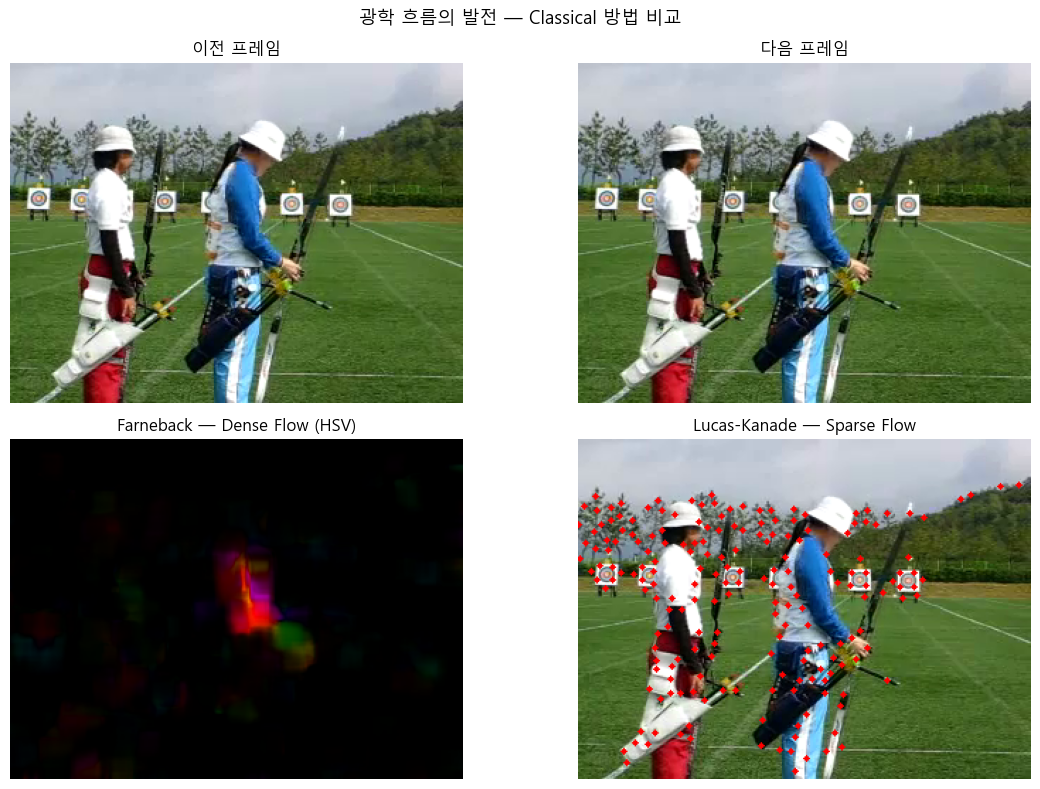

In [7]:
# ── 섹션 2 실행: 광학 흐름 비교 시각화 ──
frames = read_all_frames_bgr(video_path)
pair_idx = 10  # 10→11번 프레임 쌍 (양궁 동작 구간)
visualize_optical_flow_comparison(
    frames[pair_idx], frames[pair_idx + 1],
    save_path=OPTICAL_FLOW_DIR / f"flow_compare_{pair_idx:04d}.png",
)


## 3. SlowFast Network — Dual-pathway


| 경로 | 프레임레이트 | 해상도 | 역할 |
|------|-------------|--------|------|
| **Slow Pathway** | 낮음 (8프레임) | 원본 (고해상도) | 공간(Spatial) 의미 — 객체 형태·세부 |
| **Fast Pathway** | 높음 (α=4배) | 112×112 (저해상도) | 시간(Temporal) 움직임 — 빠른 동작 |

**핵심 아이디어:** 인간 시각계의 P-cell(고해상도·저속) / M-cell(저해상도·고속)을 모방한다. SlowFast는 3D CNN 계열에서 **연산 효율과 분석 정밀도**를 동시에 확보한 대표 아키텍처다.

> 본 실습은 SlowFast **입력 구성 원리**를 시각화한다. (torchvision SlowFast 추론은 별도 dual-tensor 파이프라인 필요)


In [8]:
def build_slowfast_pathways(
    video_path: Path, *, slow_num_frames: int = 8, alpha: int = SLOWFAST_ALPHA,
):
    """
    SlowFast Network의 이중 경로 입력 클립을 구성한다.

    Slow: 전체 길이에서 8프레임 균등 샘플링, 원본 해상도 유지
    Fast : Slow 대비 alpha(=4)배 많은 프레임, 112×112로 다운샘플
    """
    bgr_frames = read_all_frames_bgr(video_path)
    total = len(bgr_frames)

    slow_indices = sample_frame_indices(total, slow_num_frames)
    fast_count = min(slow_num_frames * alpha, total)
    fast_indices = sample_frame_indices(total, fast_count)

    slow_frames = [bgr_frames[i] for i in slow_indices]
    fast_frames = [cv2.resize(bgr_frames[i], (112, 112)) for i in fast_indices]
    return slow_frames, fast_frames


def visualize_slowfast_pathways(video_path: Path, *, save_path: Path | None = None, show: bool = True) -> None:
    """Slow / Fast 경로에서 샘플링된 프레임을 가로 모자이크로 시각화한다."""
    slow_frames, fast_frames = build_slowfast_pathways(video_path)
    fig, axes = plt.subplots(2, 1, figsize=(14, 6))
    fig.suptitle("SlowFast — Slow(공간·고해상도) + Fast(시간·저해상도)", fontsize=13)

    def _show_row(ax, frame_list, title):
        ax.set_title(title)
        ax.axis("off")
        mosaic = np.hstack([cv2.cvtColor(f, cv2.COLOR_BGR2RGB) for f in frame_list[:8]])
        ax.imshow(mosaic)

    _show_row(axes[0], slow_frames, f"Slow Pathway — {len(slow_frames)} frames, 원본 해상도")
    _show_row(axes[1], fast_frames, f"Fast Pathway — {len(fast_frames)} frames (α={SLOWFAST_ALPHA}), 112×112")
    plt.tight_layout()
    if save_path:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"[SlowFast] 저장: {save_path.resolve()}")
    if show:
        plt.show()
    else:
        plt.close(fig)


def print_architecture_comparison_table() -> None:
    """교재에 등장하는 Video Vision 아키텍처 비교 표를 출력한다."""
    rows = [
        ("C3D / R3D-18", "고정 크기 3D Conv", "단순·빠른 시공간 학습"),
        ("I3D / MC3-18", "2D 가중치 Inflation", "ImageNet 지식 전이"),
        ("SlowFast", "Slow+Fast 이중 경로", "효율·정밀도 균형"),
        ("TimeSformer", "Divided Space-Time Attention", "Joint 대비 ~10× 효율"),
        ("ViViT", "Tubelet + Factorized Attention", "시공간 튜브 단위 특징"),
        ("Swin3D", "3D Window Attention", "로컬 시공간 맥락 강화"),
    ]
    print("\n[아키텍처 비교 — 교재 요약]")
    print(f"{'Architecture':<16} {'Core Concept':<28} {'Key Advantage'}")
    print("-" * 72)
    for arch, concept, adv in rows:
        print(f"{arch:<16} {concept:<28} {adv}")


[SlowFast] 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output\slowfast\slowfast_pathways.png


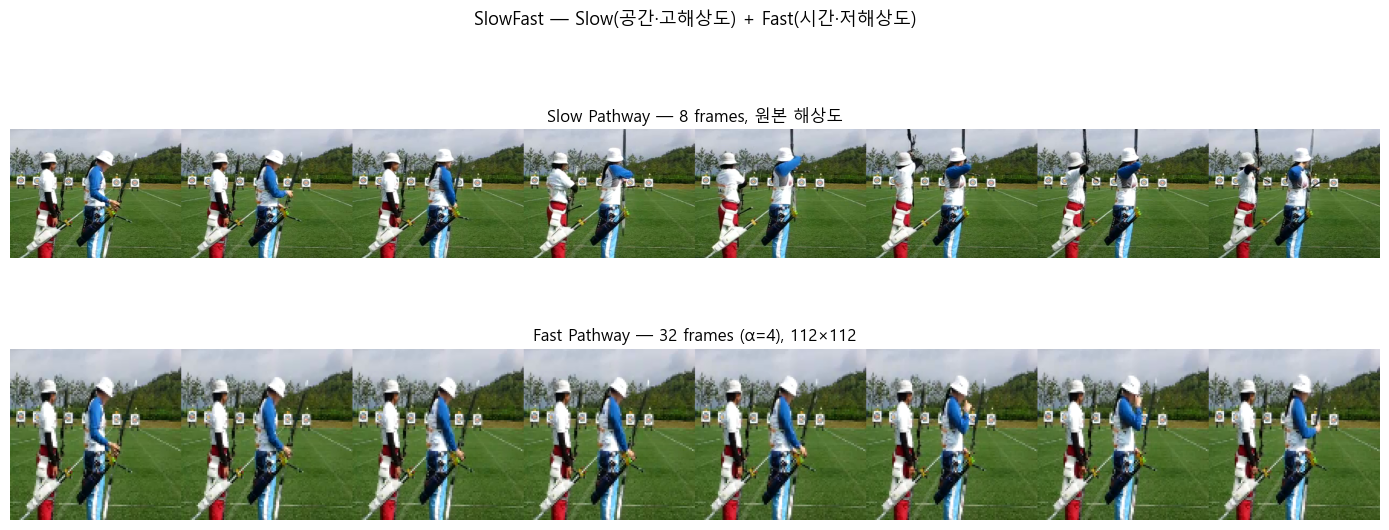


[아키텍처 비교 — 교재 요약]
Architecture     Core Concept                 Key Advantage
------------------------------------------------------------------------
C3D / R3D-18     고정 크기 3D Conv                단순·빠른 시공간 학습
I3D / MC3-18     2D 가중치 Inflation             ImageNet 지식 전이
SlowFast         Slow+Fast 이중 경로              효율·정밀도 균형
TimeSformer      Divided Space-Time Attention Joint 대비 ~10× 효율
ViViT            Tubelet + Factorized Attention 시공간 튜브 단위 특징
Swin3D           3D Window Attention          로컬 시공간 맥락 강화


In [9]:
# ── 섹션 3 실행: SlowFast 이중 경로 시각화 ──
visualize_slowfast_pathways(
    video_path,
    save_path=SLOWFAST_DIR / "slowfast_pathways.png",
)
print_architecture_comparison_table()


## 4. 3D CNN Architectures

### Vision 기술 요약

| Model | 교재 대응 | 3D Conv 원리 | 입력 | Kinetics-400 |
|-------|-----------|-------------|------|--------------|
| **R3D-18** | C3D | `(k,t,h,w)` 커널로 시공간 동시 합성곱 | 16프×112² | ResNet-18 기반 |
| **MC3-18** | I3D | Mixed Conv — 2D→3D Inflation으로 ImageNet 지식 전이 | 16프×112² | 채널별 Conv3D |
| **Swin3D-T** | Video Swin | 3D Window Attention — 로컬 시공간 패치 내 Self-Attention | 32프×224² | 계층적 Transformer |

**3D CNN vs 2D CNN:** 2D Conv는 프레임별 Spatial만, 3D Conv는 **시간 축(t)까지** 커널이 확장되어 Temporal 패턴을 직접 학습한다.

**전처리 파이프라인:** RGB 프레임(T,H,W,C) → TCHW tensor → `VideoClassification` transform(리사이즈·크롭·정규화) → CTHW → 모델 입력


In [10]:
def _prepare_torchvision_clip(video_path: Path, num_frames: int, weights) -> torch.Tensor:
    """
    OpenCV RGB 프레임 → PyTorch TCHW uint8 → torchvision transform → CTHW float32.
    weights.transforms()는 Kinetics-400 학습 시 사용된 mean/std·크롭 크기를 적용한다.
    """
    rgb_frames = read_sampled_rgb_frames(video_path, num_frames)
    tchw = torch.from_numpy(np.stack(rgb_frames)).permute(0, 3, 1, 2)  # (T,C,H,W)
    return weights.transforms()(tchw)  # → (C,T,H,W)


def predict_torchvision_video_model(
    video_path: Path, model, weights, num_frames: int, top_k: int = 5,
) -> list[tuple[str, float]]:
    """
    torchvision 3D CNN / Video Swin으로 Kinetics-400 400클래스 행동 분류를 수행한다.
    softmax 확률 기준 top-k 라벨과 확률을 반환한다.
    """
    model.eval()
    clip = _prepare_torchvision_clip(video_path, num_frames, weights).unsqueeze(0)  # 배치 차원

    with torch.no_grad():
        logits = model(clip)[0]  # shape: (400,)

    probs = F.softmax(logits, dim=0)
    k = min(top_k, probs.shape[0])
    values, indices = torch.topk(probs, k)
    categories = weights.meta["categories"]  # Kinetics-400 클래스명 리스트
    return [(categories[i], float(v)) for v, i in zip(values.tolist(), indices.tolist())]


def run_3d_cnn_benchmark(video_path: Path, top_k: int = 5) -> dict[str, list[tuple[str, float]]]:
    """
    R3D(C3D), MC3(I3D), Swin3D(Video Swin) 세 모델의 추론을 순차 실행한다.
    RUN_SWIN3D=False 이면 Swin3D-T를 건너뛴다 (가중치 ~122MB).
    """
    from torchvision.models.video import (
        R3D_18_Weights, MC3_18_Weights, Swin3D_T_Weights,
        mc3_18, r3d_18, swin3d_t,
    )
    results = {}

    print("\n[3D CNN] R3D-18 (C3D 계열) 추론...")
    w_r3d = R3D_18_Weights.DEFAULT
    results["R3D-18 (C3D)"] = predict_torchvision_video_model(
        video_path, r3d_18(weights=w_r3d), w_r3d, R3D_NUM_FRAMES, top_k)

    print("[3D CNN] MC3-18 (I3D 계열) 추론...")
    w_mc3 = MC3_18_Weights.DEFAULT
    results["MC3-18 (I3D)"] = predict_torchvision_video_model(
        video_path, mc3_18(weights=w_mc3), w_mc3, R3D_NUM_FRAMES, top_k)

    if RUN_SWIN3D:
        print("[3D CNN] Swin3D-T (Video Swin) 추론...")
        w_swin = Swin3D_T_Weights.DEFAULT
        results["Swin3D-T"] = predict_torchvision_video_model(
            video_path, swin3d_t(weights=w_swin), w_swin, SWIN3D_NUM_FRAMES, top_k)

    return results


def print_predictions(title: str, predictions: list[tuple[str, float]]) -> None:
    """Top-k 행동 인식 결과를 콘솔에 포맷팅하여 출력한다."""
    print(f"\n{title}")
    print("-" * 52)
    for rank, (label, prob) in enumerate(predictions, 1):
        print(f"  {rank}. {label:<32} {prob * 100:6.2f}%")
    print("-" * 52)
    print(f"  ▶ 최상위: {predictions[0][0]} ({predictions[0][1] * 100:.2f}%)")


In [11]:
# ── 섹션 4 실행: 3D CNN 행동 인식 ──
all_results = {}
cnn_results = run_3d_cnn_benchmark(video_path)
all_results.update(cnn_results)
for name, preds in cnn_results.items():
    print_predictions(f"[{name}] 행동 인식", preds)



[3D CNN] R3D-18 (C3D 계열) 추론...
[3D CNN] MC3-18 (I3D 계열) 추론...
[3D CNN] Swin3D-T (Video Swin) 추론...

[R3D-18 (C3D)] 행동 인식
----------------------------------------------------
  1. archery                           99.94%
  2. golf chipping                      0.02%
  3. hurling (sport)                    0.01%
  4. golf driving                       0.01%
  5. hitting baseball                   0.01%
----------------------------------------------------
  ▶ 최상위: archery (99.94%)

[MC3-18 (I3D)] 행동 인식
----------------------------------------------------
  1. archery                           99.88%
  2. golf chipping                      0.06%
  3. golf driving                       0.03%
  4. throwing axe                       0.02%
  5. chopping wood                      0.01%
----------------------------------------------------
  ▶ 최상위: archery (99.88%)

[Swin3D-T] 행동 인식
----------------------------------------------------
  1. archery                          100.00%
  2. throwing a

## 5. Video Transformer


| Model | Attention 방식 | 핵심 메커니즘 | 입력 |
|-------|---------------|--------------|------|
| **TimeSformer** | Divided (T+S) | Spatial Attention → Temporal Attention **순차 분리** | 8프×224² |
| **ViViT** | Factorized | **Tubelet**(2×16×16) 임베딩 + 시공간 축 독립 Encoder | 32프×224² |

**Space-Time Attention 3가지 :**

1. **Joint Attention (ST)** — 모든 시공간 패치에 한 번에 Attention → 연산량 최대
2. **Divided Attention (T+S)** — TimeSformer 방식, Joint 대비 **~10× 효율**
3. **Factorized Attention** — ViViT 방식, Tubelet 단위 고차원 특징 추출

**TimeSformer 파이프라인:**
`RGB 프레임 리스트` → `AutoImageProcessor`(리사이즈·정규화) → `pixel_values` 텐서 → `TimesformerForVideoClassification` → 400클래스 logits


In [12]:
def predict_timesformer(
    video_path: Path,
    model_id: str = TIMESFORMER_MODEL_ID,
    num_frames: int = TIMESFORMER_NUM_FRAMES,
    top_k: int = 5,
):
    """
    TimeSformer — Divided Space-Time Attention 기반 행동 분류.

    1) 8프레임 RGB 클립 샘플링
    2) AutoImageProcessor: 224×224 리사이즈 + mean/std 정규화
    3) TimesformerForVideoClassification: Spatial→Temporal Divided Attention
    4) softmax → top-k Kinetics-400 라벨 반환
    """
    print(f"\n[TimeSformer] 모델 로드: {model_id}")
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = TimesformerForVideoClassification.from_pretrained(model_id)
    model.eval()

    frames = read_sampled_rgb_frames(video_path, num_frames)
    inputs = processor(frames, return_tensors="pt")  # pixel_values: (1, 8, 3, 224, 224)

    tensor_info = {
        "input_shape": tuple(inputs["pixel_values"].shape),
        "attention_type": "Divided Space-Time (T+S)",
    }

    with torch.no_grad():
        logits = model(**inputs).logits[0]

    probs = torch.softmax(logits, dim=-1)
    k = min(top_k, probs.shape[0])
    values, indices = torch.topk(probs, k)
    preds = [(model.config.id2label[i], float(v)) for v, i in zip(values.tolist(), indices.tolist())]
    return preds, tensor_info


def predict_vivit(
    video_path: Path,
    model_id: str = VIVIT_MODEL_ID,
    num_frames: int = VIVIT_NUM_FRAMES,
    top_k: int = 5,
):
    """
    ViViT — Tubelet 임베딩 + Factorized Attention 기반 행동 분류.

    Tubelet: 연속 2프레임 × 16×16 패치를 하나의 3D 토큰으로 임베딩
    → 시공간 정보를 토큰 단위로 통합하여 Transformer에 입력
    """
    from transformers import VivitForVideoClassification, VivitImageProcessor

    print(f"\n[ViViT] 모델 로드: {model_id}")
    processor = VivitImageProcessor.from_pretrained(model_id)
    model = VivitForVideoClassification.from_pretrained(model_id)
    model.eval()

    frames = read_sampled_rgb_frames(video_path, num_frames)
    inputs = processor(frames, return_tensors="pt")

    tubelet = getattr(model.config, "tubelet_size", [2, 16, 16])
    tensor_info = {
        "input_shape": tuple(inputs["pixel_values"].shape),
        "tubelet_size": tubelet,
        "attention_type": "Factorized (ViViT)",
    }

    with torch.no_grad():
        logits = model(**inputs).logits[0]

    probs = torch.softmax(logits, dim=-1)
    k = min(top_k, probs.shape[0])
    values, indices = torch.topk(probs, k)
    preds = [(model.config.id2label[i], float(v)) for v, i in zip(values.tolist(), indices.tolist())]
    return preds, tensor_info


def print_space_time_attention_guide() -> None:
    """Space-Time Attention 메커니즘(교재) 핵심 설명을 출력한다."""
    print(textwrap.dedent("""
        [Space-Time Attention 메커니즘 — 교재 핵심]

          1. Joint Attention (ST)
             모든 시공간 패치에 대해 한 번에 Attention → 연산량 最高

          2. Divided Attention (T+S)  ← TimeSformer
             Spatial Attention 후 Temporal Attention 순차 적용 → ~10× 효율

          3. Factorized Attention     ← ViViT
             시공간 축을 독립 Encoder로 분해 → Tubelet 임베딩 활용

          ※ Video Swin(Swin3D)은 3D Window Attention으로 로컬 맥락을 강화한다.
    """).strip())


def print_model_comparison_summary(all_results: dict[str, list[tuple[str, float]]]) -> None:
    """모든 모델의 Top-1 예측을 한 표로 비교한다 (섹션 6 종합)."""
    print("\n[모델별 최상위 예측 비교]")
    print(f"{'Model':<22} {'Top-1 Label':<28} {'Prob'}")
    print("-" * 62)
    for model_name, preds in all_results.items():
        label, prob = preds[0]
        print(f"{model_name:<22} {label:<28} {prob * 100:5.1f}%")
    print("-" * 62)


In [13]:
# ── 섹션 5 실행: Video Transformer 행동 인식 ──
print_space_time_attention_guide()

ts_preds, ts_info = predict_timesformer(video_path)
all_results["TimeSformer"] = ts_preds
print(f"\n[TimeSformer] 입력 텐서: {ts_info['input_shape']}  ({ts_info['attention_type']})")
print_predictions("[TimeSformer] 행동 인식", ts_preds)

if RUN_VIVIT:
    vivit_preds, vivit_info = predict_vivit(video_path)
    all_results["ViViT"] = vivit_preds
    print(f"\n[ViViT] 입력 텐서: {vivit_info['input_shape']}  Tubelet={vivit_info['tubelet_size']}")
    print_predictions("[ViViT] 행동 인식", vivit_preds)


[Space-Time Attention 메커니즘 — 교재 핵심]

  1. Joint Attention (ST)
     모든 시공간 패치에 대해 한 번에 Attention → 연산량 最高

  2. Divided Attention (T+S)  ← TimeSformer
     Spatial Attention 후 Temporal Attention 순차 적용 → ~10× 효율

  3. Factorized Attention     ← ViViT
     시공간 축을 독립 Encoder로 분해 → Tubelet 임베딩 활용

  ※ Video Swin(Swin3D)은 3D Window Attention으로 로컬 맥락을 강화한다.

[TimeSformer] 모델 로드: facebook/timesformer-base-finetuned-k400


Loading weights:   0%|          | 0/249 [00:00<?, ?it/s]


[TimeSformer] 입력 텐서: (1, 8, 3, 224, 224)  (Divided Space-Time (T+S))

[TimeSformer] 행동 인식
----------------------------------------------------
  1. archery                          100.00%
  2. throwing axe                       0.00%
  3. playing paintball                  0.00%
  4. front raises                       0.00%
  5. cleaning windows                   0.00%
----------------------------------------------------
  ▶ 최상위: archery (100.00%)

[ViViT] 모델 로드: google/vivit-b-16x2-kinetics400


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]


[ViViT] 입력 텐서: (1, 32, 3, 224, 224)  Tubelet=[2, 16, 16]

[ViViT] 행동 인식
----------------------------------------------------
  1. LABEL_5                          100.00%
  2. LABEL_195                          0.00%
  3. LABEL_119                          0.00%
  4. LABEL_327                          0.00%
  5. LABEL_328                          0.00%
----------------------------------------------------
  ▶ 최상위: LABEL_5 (100.00%)


## 6. 모델 비교 요약

### Vision 기술 진화 타임라인 

```
Optical Flow (픽셀 변위)
    ↓
3D CNN — C3D → I3D → SlowFast (시공간 Conv)
    ↓
Video Transformer — TimeSformer / ViViT / Swin3D (Attention)
```

| 단계 | 대표 기법 | Temporal 정보 추출 방식 |
|------|-----------|------------------------|
| Classical | Farneback, LK | 픽셀/코너 이동 벡터 (규칙 기반) |
| 3D CNN | R3D, MC3, Swin3D | 3D Conv / 3D Window Attention |
| Transformer | TimeSformer, ViViT | Divided / Factorized Self-Attention |

동일 archery 샘플에 대해 각 모델의 Top-1 예측을 비교하여, **기법마다 행동 인식 관점이 어떻게 다른지** 확인한다.


In [14]:
# ── 섹션 6 실행: 전 모델 Top-1 비교 ──
print_model_comparison_summary(all_results)
print("결과 이미지 저장:", OUTPUT_DIR.resolve())



[모델별 최상위 예측 비교]
Model                  Top-1 Label                  Prob
--------------------------------------------------------------
R3D-18 (C3D)           archery                       99.9%
MC3-18 (I3D)           archery                       99.9%
Swin3D-T               archery                      100.0%
TimeSformer            archery                      100.0%
ViViT                  LABEL_5                      100.0%
--------------------------------------------------------------
결과 이미지 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output


# Vision 기술 요약

본 노트북에서 다룬 **Video AI / Temporal Vision** 기술을 섹션별로 한눈에 정리한 문서입니다.

---

## 0. 환경 및 데이터

| 항목 | 설명 |
|------|------|
| **입력 데이터** | PyTorchVideo 공개 `archery.mp4` (양궁 행동 클립) |
| **프레임 처리** | OpenCV `VideoCapture` — BGR numpy 배열 디코딩 |
| **시각화** | matplotlib + 한글 폰트 자동 설정 |
| **딥러닝** | PyTorch · torchvision(3D CNN) · Hugging Face Transformers |

비디오 AI의 기본 단위는 **연속 프레임 시퀀스**이며, 이후 모든 기술은 여기서 **시간 축(Temporal) 정보**를 추출하거나 학습한다.

---

## 1. 시공간(Spatiotemporal) 정보

| 구분 | Spatial Context (공간) | Temporal Context (시간) |
|------|------------------------|-------------------------|
| **정의** | 프레임 내 형태·색상·질감 | 프레임 간 변화, 움직임, 사건 순서 |
| **담당** | CNN, ViT | Optical Flow, 3D CNN, Video Transformer |
| **본 실습** | 프레임 격자 미리보기 | 프레임 차분 `|F(t+1)-F(t)|`, Motion Energy |

**핵심:** 비디오 이해 = Spatial(정적) + Temporal(동적) **결합**. 프레임 차분·Motion Energy는 가장 단순한 Temporal 특징이다.

---

## 2. 광학 흐름 (Optical Flow)

| 방법 | 유형 | 원리 |
|------|------|------|
| **Farneback** | Dense | 모든 픽셀 (dx, dy) — HSV 컬러맵 시각화 |
| **Lucas-Kanade** | Sparse | 코너 특징점 추적 — 화살표 벡터 |

**발전:** Classical → FlowNet/PWC-Net → RAFT

**HSV 규칙:** Hue=이동 방향, Value=이동 크기

---

## 3. SlowFast Network (Dual-pathway)

| 경로 | FPS | 해상도 | 역할 |
|------|-----|--------|------|
| **Slow** | 낮음 | 고해상도 | Spatial — 객체 형태·세부 |
| **Fast** | α배 높음 | 112×112 | Temporal — 빠른 움직임 |

P-cell / M-cell을 모방한 3D CNN 계열 아키텍처. **효율과 정밀도** 균형.

---

## 4. 3D CNN Architectures

| Model | 교재 | 핵심 | 입력 |
|-------|------|------|------|
| **R3D-18** | C3D | 3D Conv 시공간 동시 학습 | 16프×112² |
| **MC3-18** | I3D | 2D→3D Inflation, ImageNet 전이 | 16프×112² |
| **Swin3D-T** | Video Swin | 3D Window Attention | 32프×224² |

2D Conv(Spatial만) vs 3D Conv(**시간 축 t** 포함). Kinetics-400 400클래스 행동 분류.

---

## 5. Video Transformer

| Model | Attention | 메커니즘 | 입력 |
|-------|-----------|----------|------|
| **TimeSformer** | Divided (T+S) | Spatial → Temporal 순차 분리 | 8프×224² |
| **ViViT** | Factorized | Tubelet(2×16×16) 임베딩 | 32프×224² |

**Space-Time Attention:**
1. **Joint (ST)** — 연산량 최대
2. **Divided (T+S)** — TimeSformer, ~10× 효율
3. **Factorized** — ViViT, Tubelet 특징

---

## 6. 기술 진화 타임라인 

```
Optical Flow (픽셀 변위, 규칙 기반)
        ↓
3D CNN — C3D → I3D → SlowFast (시공간 Convolution)
        ↓
Video Transformer — TimeSformer / ViViT / Swin3D (Self-Attention)
```

| 단계 | Temporal 정보 추출 |
|------|-------------------|
| Classical | Farneback, Lucas-Kanade |
| 3D CNN | 3D Conv, 3D Window Attention |
| Transformer | Divided / Factorized Attention |

---

## 아키텍처 한눈에 비교

| Architecture | Core Concept | Key Advantage |
|--------------|--------------|---------------|
| C3D / R3D-18 | 고정 3D Conv | 단순·빠른 시공간 학습 |
| I3D / MC3-18 | 2D 가중치 Inflation | ImageNet 지식 전이 |
| SlowFast | Slow+Fast 이중 경로 | 효율·정밀도 균형 |
| Swin3D | 3D Window Attention | 로컬 시공간 맥락 |
| TimeSformer | Divided Space-Time | Joint 대비 ~10× 효율 |
| ViViT | Tubelet + Factorized | 시공간 튜브 단위 특징 |

---

> **실습 결론:** archery 샘플에 대해 R3D-18·TimeSformer 등 대부분 모델이 **archery**를 Top-1로 예측 — Temporal Vision 파이프라인이 동일 행동 클립을 일관되게 인식함을 확인할 수 있다.
